In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn import svm, datasets

In [ ]:
cancer = datasets.load_breast_cancer()

In [9]:
print(cancer.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [10]:
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [11]:
print(cancer.data.shape)

(569, 30)


In [12]:
print(cancer.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 

In [ ]:
X = cancer.data[:, :2]
Y = cancer.target

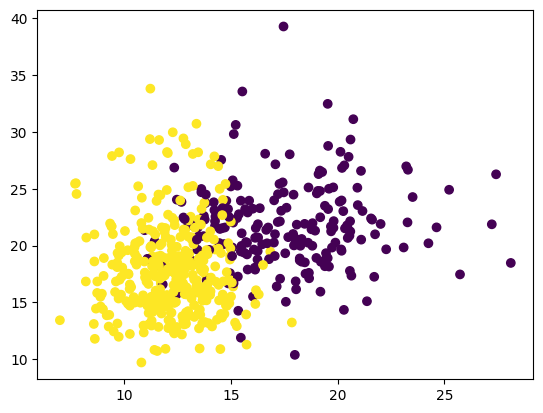

In [14]:
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.title("")
plt.show()

### Linear Functions always follow Convex Hull

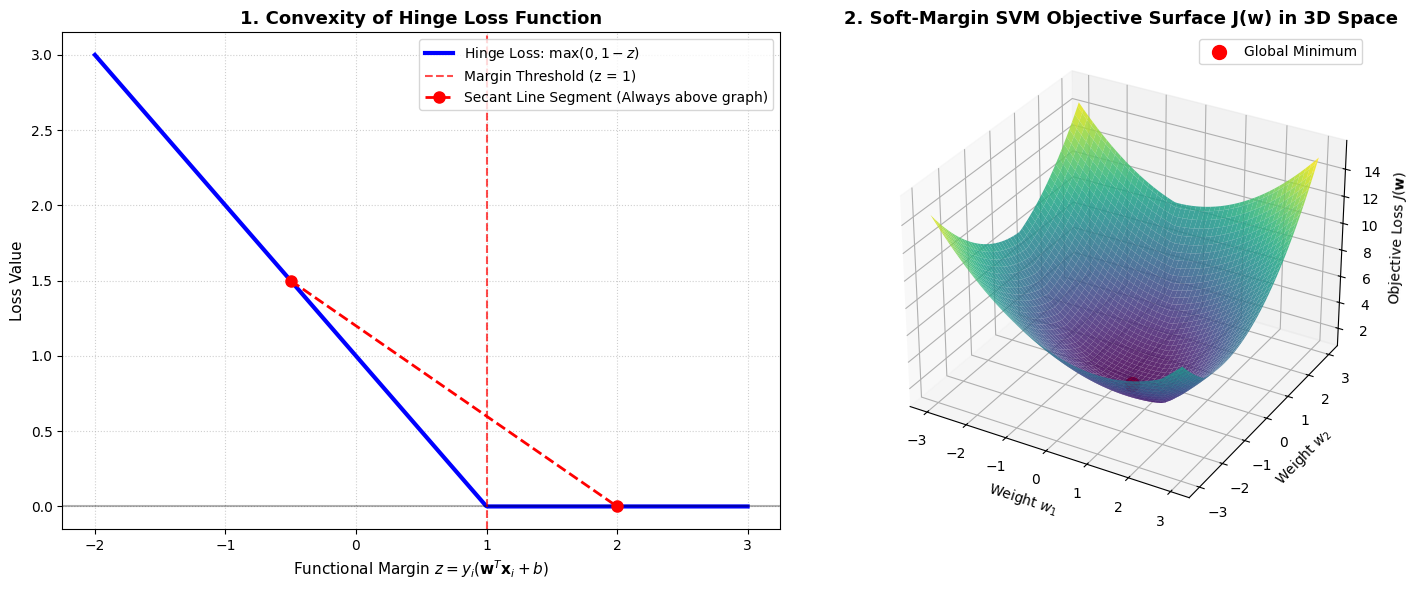

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure canvas with two side-by-side subplots
fig = plt.figure(figsize=(15, 6))

# -------------------------------------------------------------------
# SUBPLOT 1: 1D Hinge Loss Function - max(0, 1 - z)
# -------------------------------------------------------------------
ax1 = fig.add_subplot(121)

# Margin distance variable: z = y_i * (w^T * x_i + b)
z = np.linspace(-2, 3, 500)
hinge_loss = np.maximum(0, 1 - z)

# Plot Hinge Loss curve
ax1.plot(z, hinge_loss, "b-", linewidth=3, label=r"Hinge Loss: $\max(0, 1 - z)$")
ax1.axvline(
    x=1,
    color="r",
    linestyle="--",
    alpha=0.7,
    label="Margin Threshold (z = 1)",
)
ax1.axhline(y=0, color="k", linestyle="-", alpha=0.3)

# Pick two arbitrary points to construct a chord showing convexity
z1, z2 = -0.5, 2.0
loss1, loss2 = np.maximum(0, 1 - z1), np.maximum(0, 1 - z2)

# Draw secant line segment connecting the two points
ax1.plot(
    [z1, z2],
    [loss1, loss2],
    "ro--",
    linewidth=2,
    markersize=8,
    label="Secant Line Segment (Always above graph)",
)

ax1.set_title(
    "1. Convexity of Hinge Loss Function", fontsize=13, fontweight="bold"
)
ax1.set_xlabel(r"Functional Margin $z = y_i(\mathbf{w}^T \mathbf{x}_i + b)$", fontsize=11)
ax1.set_ylabel("Loss Value", fontsize=11)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right")

# -------------------------------------------------------------------
# SUBPLOT 2: 3D Objective Surface J(w1, w2) - Convex Bowl Shape
# -------------------------------------------------------------------
ax2 = fig.add_subplot(122, projection="3d")

# Create grid mesh for weight parameters w1 and w2
w1 = np.linspace(-3, 3, 100)
w2 = np.linspace(-3, 3, 100)
W1, W2 = np.meshgrid(w1, w2)

# Compute Objective Surface J(W1, W2) = 0.5 * ||w||^2 + C * Sum(Hinge Loss)
L2_reg = 0.5 * (W1**2 + W2**2)
hinge_sum = np.maximum(0, 1 - (W1 * 1.0 + W2 * 0.5)) + np.maximum(
    0, 1 - (-W1 * 0.5 - W2 * 1.2)
)
C = 1.0
J = L2_reg + C * hinge_sum

# Plot 3D surface
surf = ax2.plot_surface(
    W1, W2, J, cmap="viridis", edgecolor="none", alpha=0.85
)

# Locate Global Minimum
min_idx = np.unravel_index(np.argmin(J), J.shape)
w1_min, w2_min, J_min = W1[min_idx], W2[min_idx], J[min_idx]

# Highlight Global Minimum point
ax2.scatter(
    [w1_min],
    [w2_min],
    [J_min],
    color="red",
    s=100,
    marker="o",
    label="Global Minimum",
)

ax2.set_title(
    "2. Soft-Margin SVM Objective Surface J(w) in 3D Space",
    fontsize=13,
    fontweight="bold",
)
ax2.set_xlabel(r"Weight $w_1$", fontsize=10)
ax2.set_ylabel(r"Weight $w_2$", fontsize=10)
ax2.set_zlabel(r"Objective Loss $J(\mathbf{w})$", fontsize=10)
ax2.legend()

plt.tight_layout()
plt.show()

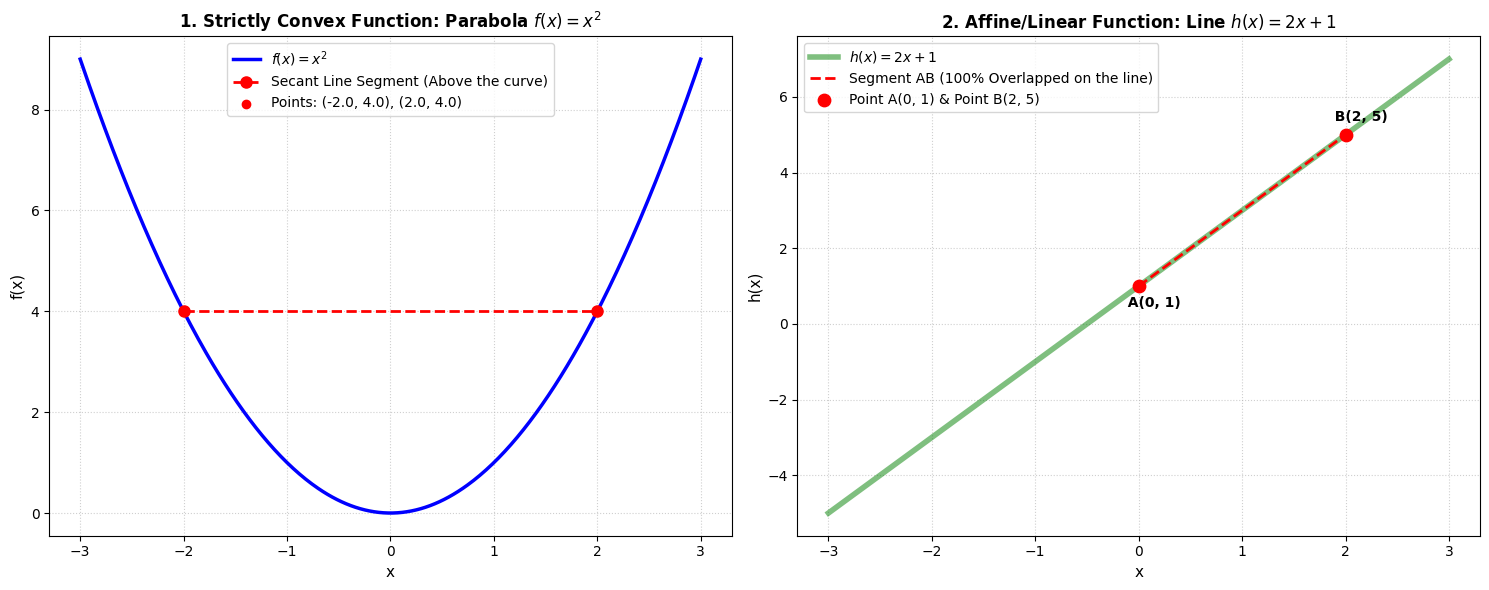

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure canvas with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# -------------------------------------------------------------------
# SUBPLOT 1: Parabola f(x) = x^2 (Strictly Convex Function)
# -------------------------------------------------------------------
x = np.linspace(-3, 3, 400)
fx = x**2

# Plot parabola curve
ax1.plot(x, fx, "b-", linewidth=2.5, label=r"$f(x) = x^2$")

# Define two points on the parabola
x1, x2 = -2.0, 2.0
y1, y2 = x1**2, x2**2

# Plot secant line segment connecting the two points
ax1.plot(
    [x1, x2],
    [y1, y2],
    "ro--",
    linewidth=2,
    markersize=8,
    label="Secant Line Segment (Above the curve)",
)

# Highlight points
ax1.scatter(
    [x1, x2], [y1, y2], color="red", zorder=5, label=f"Points: ({x1}, {y1}), ({x2}, {y2})"
)

ax1.set_title(
    "1. Strictly Convex Function: Parabola $f(x) = x^2$",
    fontsize=12,
    fontweight="bold",
)
ax1.set_xlabel("x", fontsize=11)
ax1.set_ylabel("f(x)", fontsize=11)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper center")

# -------------------------------------------------------------------
# SUBPLOT 2: Line h(x) = 2x + 1 (Affine / Linear Function)
# -------------------------------------------------------------------
hx = 2 * x + 1

# Plot linear function
ax2.plot(x, hx, "g-", linewidth=4, alpha=0.5, label=r"$h(x) = 2x + 1$")

# Define Point A(0, 1) and Point B(2, 5)
xA, yA = 0, 1
xB, yB = 2, 5

# Plot line segment connecting Point A and Point B
ax2.plot(
    [xA, xB],
    [yA, yB],
    "r--",
    linewidth=2,
    label="Segment AB (100% Overlapped on the line)",
)

# Highlight Point A and Point B
ax2.scatter(
    [xA, xB],
    [yA, yB],
    color="red",
    s=80,
    zorder=5,
    label=f"Point A({xA}, {yA}) & Point B({xB}, {yB})",
)

# Annotate Point A and Point B
ax2.annotate(
    f"  A({xA}, {yA})",
    (xA, yA),
    textcoords="offset points",
    xytext=(-15, -15),
    fontweight="bold",
)
ax2.annotate(
    f"  B({xB}, {yB})",
    (xB, yB),
    textcoords="offset points",
    xytext=(-15, 10),
    fontweight="bold",
)

ax2.set_title(
    "2. Affine/Linear Function: Line $h(x) = 2x + 1$",
    fontsize=12,
    fontweight="bold",
)
ax2.set_xlabel("x", fontsize=11)
ax2.set_ylabel("h(x)", fontsize=11)
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

### Apply Dual SVM

In [24]:
y = np.where(Y <= 0, -1, 1).astype(int)

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [47]:
n = X.shape[0]
C = 1.0

In [46]:
from cvxopt import matrix, solvers

# Gram matrix using Linear Inner Product: X_i^T * X_j
P = matrix(np.outer(y, y) * np.dot(X_scaled, X_scaled.T))
q = matrix(-np.ones(n))

In [52]:
# Bounds constraints: 0 <= alpha_i <= C
# Expressed as: -alpha_i <= 0 AND alpha_i <= C
G = matrix(np.vstack((-np.eye(n), np.eye(n))))
h = matrix(np.hstack((np.zeros(n), (np.ones(n) * C))))

In [63]:
# Equality constraint: sum(alpha_i * y_i) = 0
A = matrix(y, (1, n), 'd') # matrix(data, (row_num, col_num))
b = matrix(0.0)

In [64]:
# Solve Convex Optimization Problem
solvers.options["show_progress"] = False
solution = solvers.qp(P, q, G, h, A, b)
alphas = np.ravel(solution['x'])

In [68]:
alphas.shape

(569,)

In [70]:
# Recover Primal Weight Vector: w = sum(alpha_i * y_i * x_i)
w = np.sum((alphas * y)[:, np.newaxis]* X, axis = 0)

In [71]:
# Extract Support Vectors (alpha > 1e-4)
is_sv = alphas > 1e-4
support_vectos = X[is_sv]
sv_alphas = alphas[is_sv]
sv_y = y[is_sv]

In [72]:
margin_sv_idx = np.where((alphas > 1e-4) & (alphas < C - 1e-4))[0]
if len(margin_sv_idx) > 0:
    b_val = np.mean(
        [y[k] - np.dot(w, X[k]) for k in margin_sv_idx]
    )  # Average for stability
else:
    b_val = sv_y[0] - np.dot(w, support_vectors[0])